In [2]:
import pandas as pd

df = pd.read_csv('/content/Mall_Customers.csv')
display(df.head())
display(df.info())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

## Explore and preprocess the data

### Subtask:
Examine the dataset, handle missing values, and preprocess the features for K-Means clustering (e.g., scaling numerical features).

Check for missing values, identify numerical features for clustering, select them, and scale them using StandardScaler.



In [4]:
print("Missing values before handling:")
print(df.isnull().sum())

# Identify numerical features for clustering (excluding CustomerID)
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Select only the numerical features
df_numerical = df[numerical_features]

# Scale the selected numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_numerical_features = scaler.fit_transform(df_numerical)

# Display the shape of the scaled features
print("\nShape of scaled numerical features:")
print(scaled_numerical_features.shape)

Missing values before handling:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Shape of scaled numerical features:
(200, 3)


## Determine the optimal number of clusters (k)

Use methods like the elbow method or silhouette score to find the optimal number of clusters for K-Means.


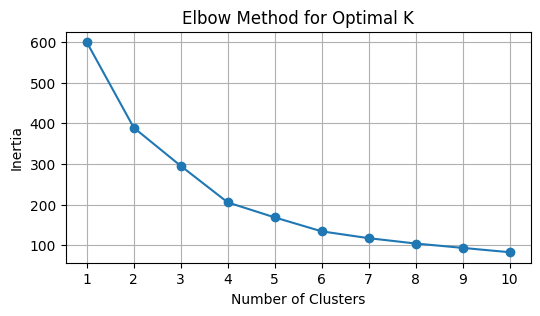

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_numerical_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Reasoning**:
Calculate the silhouette scores for a range of cluster numbers and visualize the results to help determine the optimal k, and then compare it with the optimal k from the elbow method.

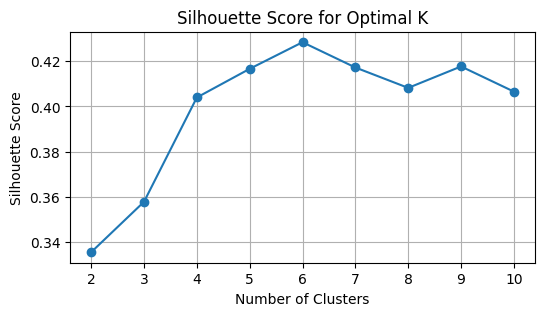

In [10]:
from sklearn.metrics import silhouette_score

# Based on the elbow plot, 5 appears to be the optimal number of clusters.
optimal_k = 5

silhouette_scores = []
for i in range(2, 11):  # Silhouette score is not defined for k=1
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_numerical_features)
    silhouette_scores.append(silhouette_score(scaled_numerical_features, kmeans.labels_))

plt.figure(figsize=(6, 3))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()



In [11]:
# Compare with elbow method result
print(f"Optimal k from Elbow Method: {optimal_k}")
# Find the k with the highest silhouette score
optimal_k_silhouette = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal k from Silhouette Score: {optimal_k_silhouette}")

Optimal k from Elbow Method: 5
Optimal k from Silhouette Score: 6


## Apply k-means clustering
Train the K-Means model with the optimal number of clusters and assign cluster labels to the data points.


In [12]:
from sklearn.cluster import KMeans

# Based on the elbow plot, 5 appears to be the optimal number of clusters.
optimal_k = 5

# Instantiate and fit the KMeans model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(scaled_numerical_features)

# Get the cluster labels
cluster_labels = kmeans.labels_

# Add the cluster labels to the original DataFrame
df['Cluster'] = cluster_labels

# Display the first few rows of the DataFrame with the new cluster column
display(df.tail(30))

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
170,171,Male,40,87,13,3
171,172,Male,28,87,75,2
172,173,Male,36,87,10,3
173,174,Male,36,87,92,2
174,175,Female,52,88,13,3
175,176,Female,30,88,86,2
176,177,Male,58,88,15,3
177,178,Male,27,88,69,2
178,179,Male,59,93,14,3
179,180,Male,35,93,90,2


## Visualize the clusters

Visualize the clusters to understand the grouping of the data points.


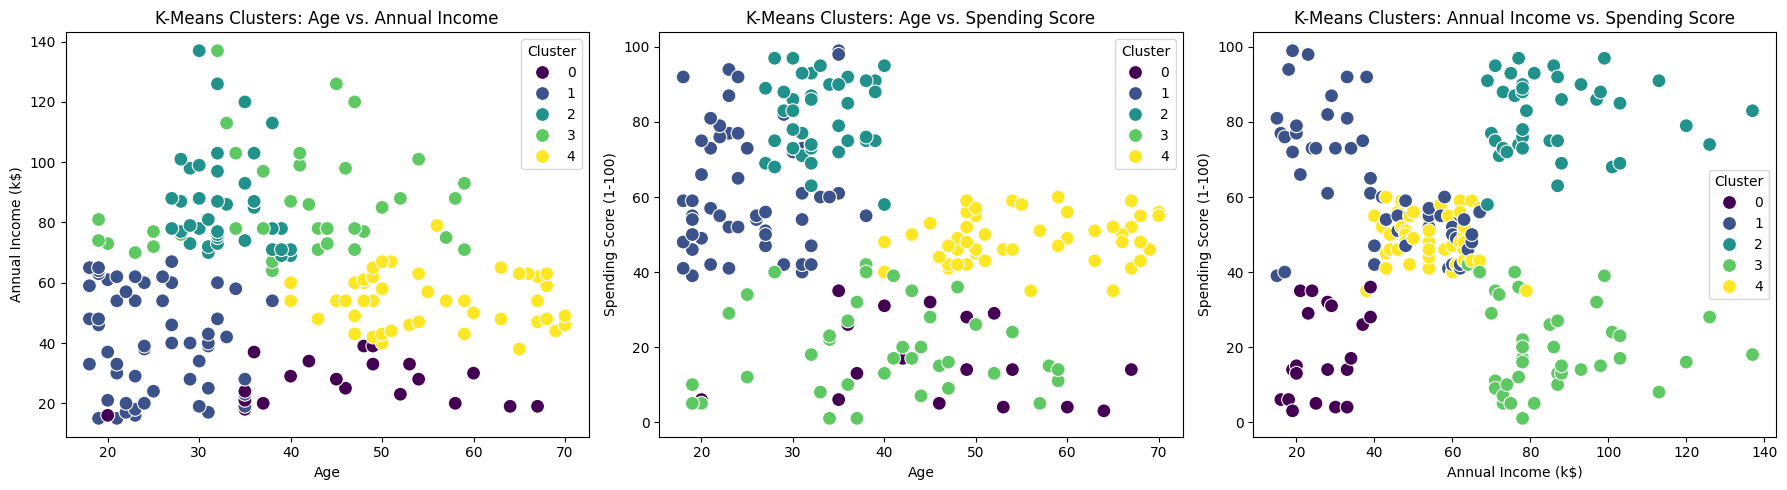

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# Age vs Annual Income
plt.subplot(1, 3, 1)
sns.scatterplot(x='Age', y='Annual Income (k$)', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('K-Means Clusters: Age vs. Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')

# Age vs Spending Score
plt.subplot(1, 3, 2)
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('K-Means Clusters: Age vs. Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')

# Annual Income vs Spending Score
plt.subplot(1, 3, 3)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('K-Means Clusters: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

## Interpret the results

Analyze the characteristics of each cluster to gain insights into the customer segments.


In [14]:
cluster_characteristics = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
display(cluster_characteristics)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


## Summary:

### Data Analysis Key Findings

*   The dataset contains 200 entries with no missing values across 'CustomerID', 'Gender', 'Age', 'Annual Income (k\$)', and 'Spending Score (1-100)'.
*   The numerical features ('Age', 'Annual Income (k\$)', and 'Spending Score (1-100)') were successfully scaled for clustering.
*   Based on the elbow method, 5 was chosen as the optimal number of clusters.
*   K-Means clustering with 5 clusters was applied, and cluster labels were assigned to each customer.
*   Analysis of the cluster characteristics revealed distinct customer segments based on age, annual income, and spending score:
    *   **Cluster 0:** Older, lower income, low spending.
    *   **Cluster 1:** Younger, moderate income, high spending.
    *   **Cluster 2:** Younger to middle-aged, high income, very high spending (high-spending customers).
    *   **Cluster 3:** Middle-aged, high income, low spending.
    *   **Cluster 4:** Older, moderate income, moderate spending.

### Insights or Next Steps

*   The identified customer segments can be used for targeted marketing campaigns and personalized offers.
*   Further analysis could involve exploring the gender distribution within each cluster and potentially incorporating gender into the clustering process.


## Perform Hierarchical Clustering and Visualize Dendrogram

Apply hierarchical clustering to the scaled data and visualize the results using a dendrogram to understand the structure of the clusters.

Perform hierarchical clustering using the `ward` linkage method and visualize the resulting dendrogram to help determine the number of clusters and understand their relationships.

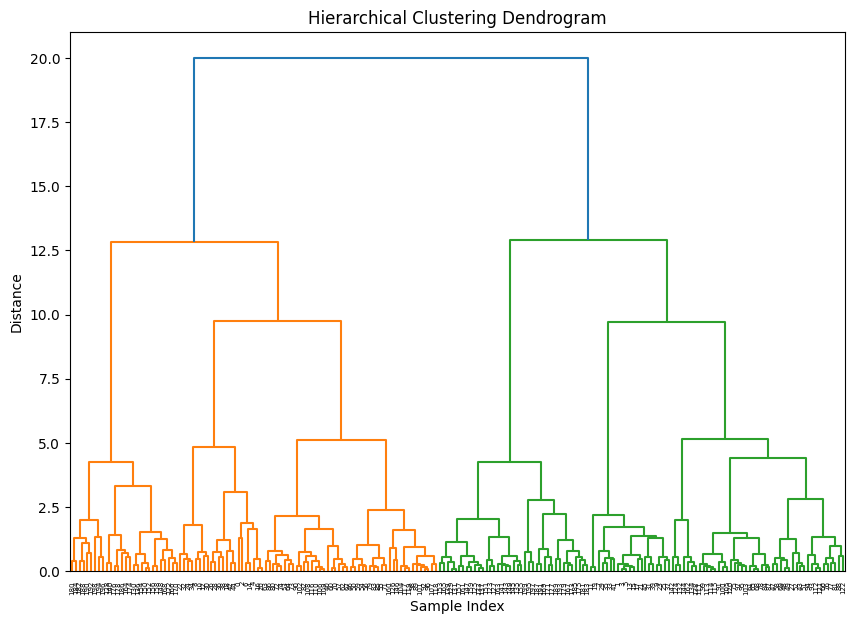

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Perform hierarchical clustering using the ward linkage method
linked = linkage(scaled_numerical_features, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='decreasing', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

**How to Read a Dendrogram:**  A dendrogram is a tree-like diagram that shows the arrangement of clusters produced by hierarchical clustering. Here's how to read it:

*   *Leaves*: The individual data points or samples are at the bottom (the leaves of the tree).
*   *Branches*: The branches represent clusters. When two branches merge, it means the clusters they represent have been combined.
*   *Height of the Merge*: The vertical line where branches merge indicates the distance or dissimilarity between the clusters that were combined. The higher the merge point, the more dissimilar the clusters were.
*   *Determining the Number of Clusters*: To decide on the optimal number of clusters, you can draw a horizontal line across the dendrogram at a certain distance. The number of vertical lines (or branches) that this horizontal line intersects is the number of clusters at that distance. You typically look for a point where there is a large vertical distance before the next merge, as this suggests distinct clusters.

*   *Ward Method (Ward's Linkage)*:

The **Ward method** is a linkage criterion used in hierarchical clustering. It determines the distance between two clusters based on the increase in the total within-cluster variance after merging them.

*Goal*: The Ward method aims to minimize the variance within each cluster and, consequently, the sum of squared distances from each point to the centroid of its cluster.
*How it works*: When considering merging two clusters, the Ward method calculates the change in the total within-cluster sum of squares that would result from the merge. It then chooses to merge the two clusters that result in the minimum increase in this sum of squares. This tends to produce clusters that are roughly equal in size and compact.
In essence, the Ward method is a greedy algorithm that tries to find the most "homogeneous" clusters at each step of the hierarchical clustering process.

## Apply DBSCAN clustering

### Subtask:
Apply DBSCAN clustering to the scaled data and analyze the results.
Apply DBSCAN to the scaled numerical features and then display the number of clusters and noise points found.

In [16]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
# You may need to adjust eps and min_samples based on your data
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_numerical_features)

# Add the DBSCAN labels to the original DataFrame
df['DBSCAN_Cluster'] = dbscan_labels

# Analyze the results
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# Display the first few rows with the new DBSCAN cluster column
display(df.head())

Estimated number of clusters: 6
Estimated number of noise points: 60


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN_Cluster
0,1,Male,19,15,39,1,-1
1,2,Male,21,15,81,1,0
2,3,Female,20,16,6,0,-1
3,4,Female,23,16,77,1,0
4,5,Female,31,17,40,1,-1


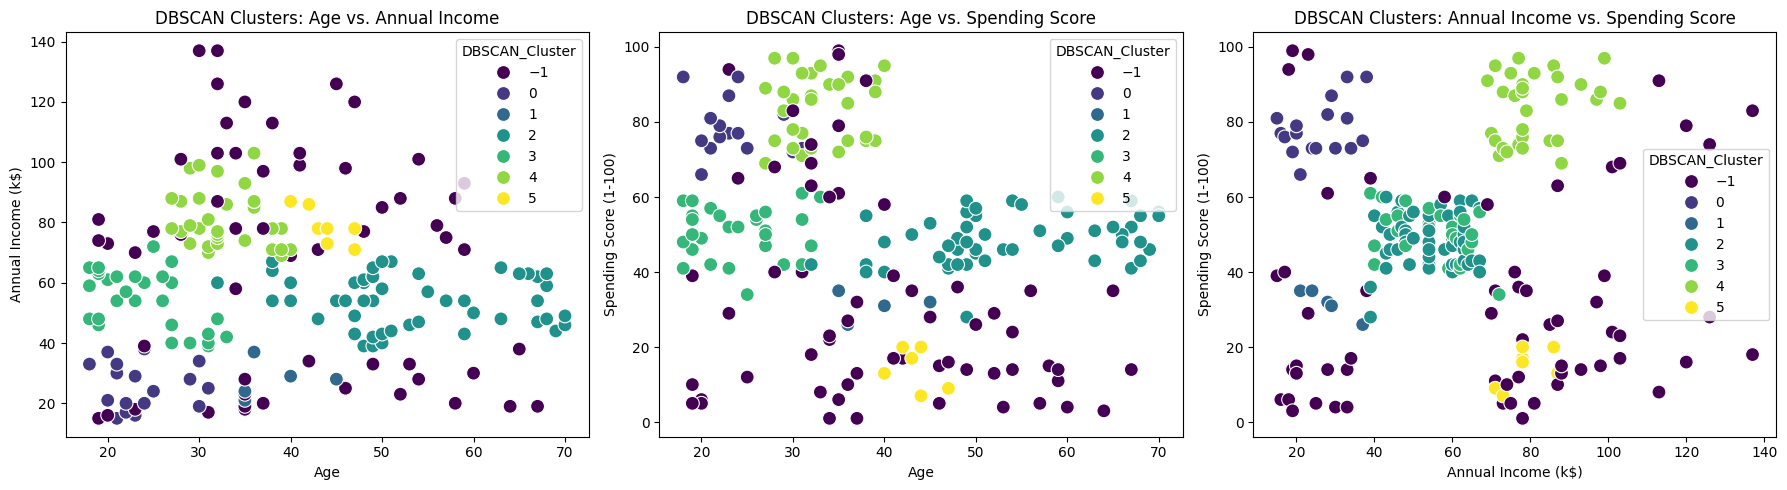

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# Age vs Annual Income
plt.subplot(1, 3, 1)
sns.scatterplot(x='Age', y='Annual Income (k$)', hue='DBSCAN_Cluster', data=df, palette='viridis', s=100)
plt.title('DBSCAN Clusters: Age vs. Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')

# Age vs Spending Score
plt.subplot(1, 3, 2)
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df, palette='viridis', s=100)
plt.title('DBSCAN Clusters: Age vs. Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')

# Annual Income vs Spending Score
plt.subplot(1, 3, 3)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df, palette='viridis', s=100)
plt.title('DBSCAN Clusters: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

In DBSCAN (Density-Based Spatial Clustering of Applications with Noise), the cluster label -1 is specifically reserved for noise points or outliers.


DBSCAN works by grouping together data points that are closely packed together, marking as outliers those points that lie alone in low-density regions.

- **Core Points**: A point is a core point if there are at least min_samples (a parameter you set) data points within a distance eps (another parameter you set) of it. These form the 'dense' parts of clusters.

- **Border Points**: A point is a border point if it's within eps distance of a core point but isn't a core point itself.
Noise Points (-1): Any point that is neither a core point nor a border point is considered a noise point and is assigned the label -1. These are the points that don't belong to any cluster based on the density criteria defined by eps and min_samples.

So, when you see a cluster label of -1, it means that the DBSCAN algorithm identified that particular data point as an outlier or noise, not belonging to any of the identified density-based clusters (which are labeled 0, 1, 2, and so on). In our case, 60 points were identified as noise.

**Reasoning**:
Group the dataframe by the DBSCAN cluster and calculate the mean of the numerical columns for each cluster, including the noise points (labeled as -1).

In [18]:
# Analyze the characteristics of each DBSCAN cluster
# Group by 'DBSCAN_Cluster' and calculate the mean of the numerical features
dbscan_cluster_characteristics = df.groupby('DBSCAN_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Display the characteristics of each cluster
display(dbscan_cluster_characteristics)

,Age,Annual Income (k$),Spending Score (1-100)
DBSCAN_Cluster,,,
-1,40.133333,68.533333,31.533333
0,23.764706,25.823529,78.176471
1,38.200000,27.800000,31.800000
2,53.666667,54.156863,48.411765
3,24.107143,54.321429,50.464286
4,32.750000,80.875000,83.625000
5,43.857143,78.714286,14.571429


In [19]:
print("\nK-Means Cluster Characteristics:")
display(cluster_characteristics)

print("\nDBSCAN Cluster Characteristics:")
display(dbscan_cluster_characteristics)


K-Means Cluster Characteristics:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064



DBSCAN Cluster Characteristics:


,Age,Annual Income (k$),Spending Score (1-100)
DBSCAN_Cluster,,,
-1,40.133333,68.533333,31.533333
0,23.764706,25.823529,78.176471
1,38.200000,27.800000,31.800000
2,53.666667,54.156863,48.411765
3,24.107143,54.321429,50.464286
4,32.750000,80.875000,83.625000
5,43.857143,78.714286,14.571429
